# Odszumianie zaszumionego sygnału czujnika procesowego za pomocą PROC LOESS

## Streszczenie

Czujnik temperatury komory pieca na linii produkcyjnej jest próbkowany raz na sekundę podczas rozruchu, więc każdy odczyt miesza powolny nieliniowy przebieg termiczny (szybkie narastanie podczas rozgrzewania, przeregulowanie przy ustalaniu się, a następnie powrót w kierunku wartości zadanej 300°C) ze znacznym szumem pomiarowym. Ten notatnik używa **PROC LOESS** do nieparametrycznego odzyskania sygnału źródłowego. Dla 100-próbkowego dziennika AICC wybrało parametr wygładzania 0.08 (8 równoważnych parametrów); powstała krzywa ściśle śledzi sygnał ukryty, pozostawiając reszty o odchyleniu standardowym 3.10°C — zasadniczo ten sam szum 4°C, który wprowadziliśmy, pomniejszony o wariancję wyjaśnioną przez dopasowanie. Względem znanej prawdy odniesienia, oszacowanie LOESS obniża błąd średniokwadratowy z 14.77 (dane surowe) do 6.63, a krok SCORE ponownie próbkuje odszumiony sygnał na jednorodną siatkę monitorującą do dalszej statystycznej kontroli procesu.

## Źródła danych

| Zbiór danych | Wiersze | Zmienne | Opis |
|---------|------|-----------|-------------|
| `sensor` | 100 | `t` (sekundy od początku, 0–99), `temp` (obserwowana temperatura komory, °C), `truth` (ukryty sygnał bez szumu, tylko do walidacji) | Syntetyczny dziennik czujnika pieca, jedna próbka na sekundę. Sygnał ukryty to szybkie narastanie w kierunku wartości zadanej 300°C z tłumionym przeregulowaniem, które osiąga szczyt w pobliżu t = 28 (~295°C), następnie opada i ustala się w kierunku wartości zadanej; obserwowana `temp` dodaje gaussowski szum pomiarowy (odch. std ~4°C). |
| `grid` | 60 | `t` (jednorodna siatka monitorująca 0–99) | Regularna siatka czasowa używana przez instrukcję SCORE do wygenerowania równomiernie rozmieszczonego odszumionego sygnału do wykresu SPC. |

W linii produkcyjnej czujnik komory pieca rejestruje temperaturę raz na sekundę podczas rozruchu. Odczyt, który zapisujemy, to **rzeczywisty stan termiczny plus szum pomiarowy**. Rzeczywisty stan nie podąża za żadnym czystym wzorem parametrycznym — narasta podczas rozgrzewania, przekracza wartość zadaną, a następnie się ustala — więc globalne dopasowanie liniowe lub wielomianowe byłoby słabym modelem.

**Regresja lokalna (LOESS)** jest właściwym narzędziem: dopasowuje wielomiany niskiego stopnia do przesuwających się lokalnych sąsiedztw, odzyskując dowolny gładki sygnał bez konieczności określania jego postaci funkcyjnej. W tym notatniku:

1. Symulujemy realistyczny zaszumiony 100-próbkowy dziennik czujnika.
2. Pozwalamy, aby `PROC LOESS` samodzielnie dobrał przepustowość wygładzania za pomocą kryterium AICC.
3. Dołączamy 95-procentowy przedział ufności do dopasowanego sygnału.
4. Oceniamy model na regularnej siatce do dalszej kontroli SPC.
5. Ilościowo określamy, ile szumu usunęliśmy.

## Krok 1 — Symulacja dziennika czujnika

Generujemy 100 próbek w przedziale 0–99 sekund. Sygnał ukryty `truth` to szybkie narastanie w kierunku wartości zadanej 300°C z tłumionym przeregulowaniem — kształt, którego żadna prosta ani pojedynczy wielomian nie odwzoruje dobrze: gwałtownie rośnie, osiąga szczyt powyżej wartości zadanej w pobliżu t = 28, opada, a następnie się ustala. Obserwowana `temp` dodaje gaussowski szum pomiarowy. `call streaminit` ustala ziarno losowania, dzięki czemu przebieg jest odtwarzalny.

In [1]:
DANE sensor;
    CALL streaminit(70421);
    setpoint = 300;
    POWTÓRZ t = 0 TO 99;
        /* Sygnał ukryty: szybkie narastanie + tłumione przeregulowanie */
        ramp      = setpoint * (1 - EXP(-t / 10));
        overshoot = 40 * EXP(-t / 35) * sin(t / 11);
        truth     = ramp + overshoot;
        /* Obserwowany odczyt = truth + szum pomiarowy (odch. std ~4 C) */
        temp = truth + rand('NORMAL', 0, 4);
        WYJŚCIE;
    KONIEC;
    ZACHOWAJ t temp truth;
WYKONAJ;

PROCEDURA DRUKUJ DANE=sensor(obs=8) noobs label;
    ETYKIETA t='Czas (s)' temp='Temperatura (C)' truth='Sygnał rzeczywisty (C)';
    TYTUŁ 'Pierwsze 8 odczytów czujnika';
WYKONAJ;

                                              Pierwsze 8 odczytów czujnika                                              

Czas (s)  Temperatura (C)   Sygnał rzeczywisty (C)
       0     0.1684867131                        0
       1    28.1933107495            32.0778466448
       2    61.6123615699            61.2117857105
       3    85.5053781561             87.643846097
       4   110.5560474248           111.5945193774
       5   136.6368358359           133.2650493509
       6   144.2434193147           152.8394750856
       7   177.8286488692           170.4864506364

... 92 more observations (showing 8 of 100)




NOTE: DATA sensor


NOTE: Wrote sensor (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=sensor

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Krok 2 — Przegląd surowego sygnału

Szybki wykres punktowy pokazuje problem: leżący u podstaw dryf jest oczywisty dla oka, ale ukryty pod szumem między kolejnymi próbkami. Potrzebujemy oszacowania gładkiej krzywej, a nie rozedrganych punktów.

                                              Pierwsze 8 odczytów czujnika                                              




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=sensor

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


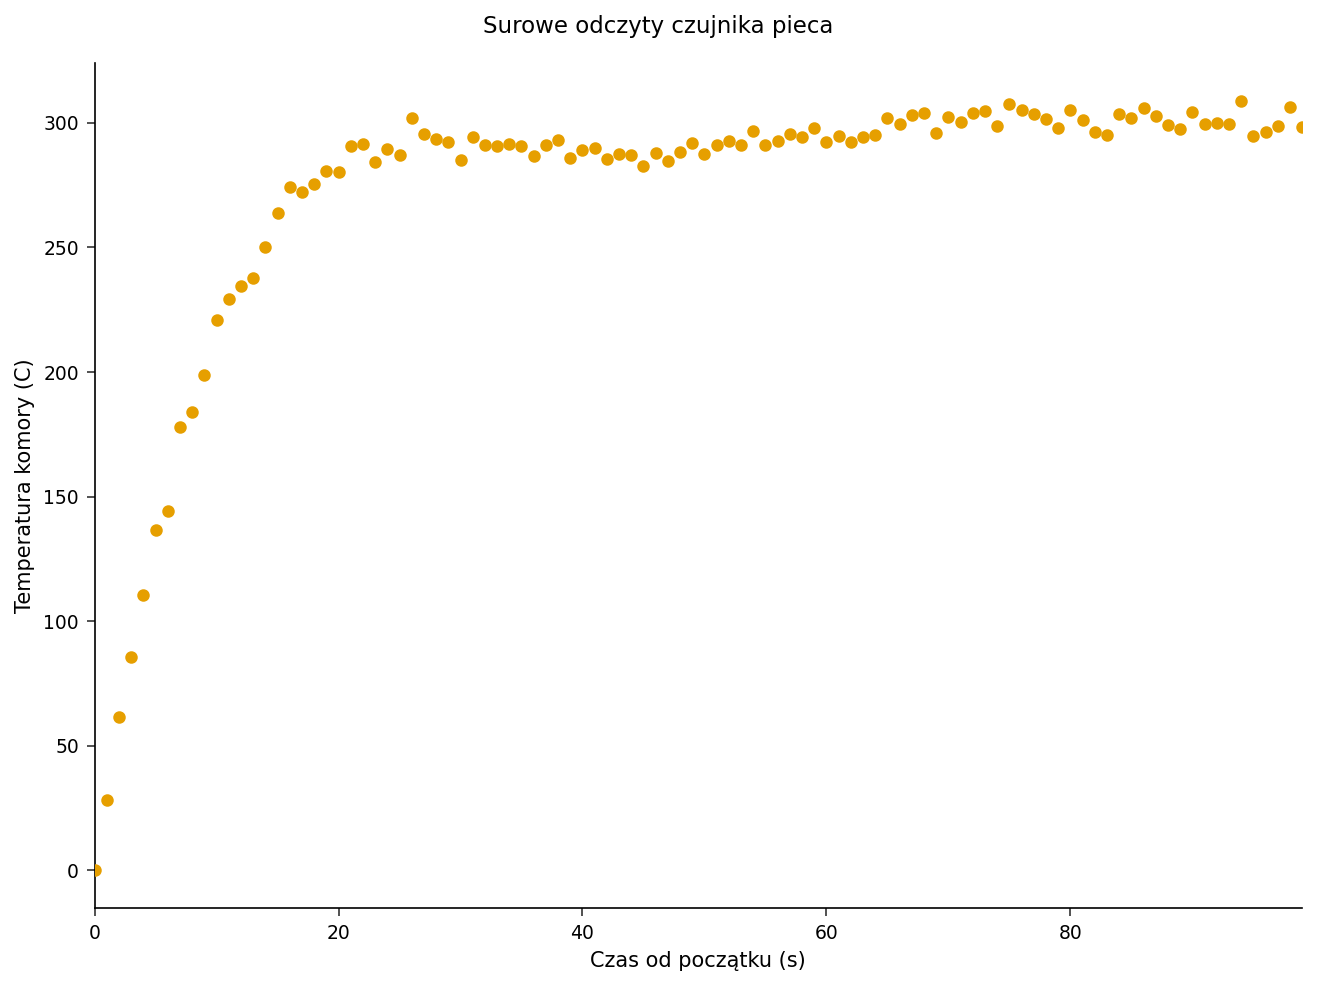

In [2]:
ODS GRAPHICS ON;

PROCEDURA SGPLOT DANE=sensor;
    SCATTER x=t y=temp / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS ETYKIETA='Czas od początku (s)';
    YAXIS ETYKIETA='Temperatura komory (C)';
    TYTUŁ 'Surowe odczyty czujnika pieca';
WYKONAJ;

ODS GRAPHICS OFF;

## Krok 3 — Dopasowanie LOESS z automatycznym doborem przepustowości

Parametr wygładzania kontroluje, jak szerokie jest każde lokalne sąsiedztwo: zbyt mały przeucza szum, zbyt duży zaciera przeregulowanie. Zamiast zgadywać, pozwalamy, aby LOESS dobrał go, minimalizując **skorygowane kryterium informacyjne Akaikego** za pomocą `select=AICC`. Używamy lokalnych wielomianów kwadratowych (`degree=2`), aby krzywa mogła podążać za krzywizną rozgrzewania i przeregulowania, oraz żądamy 95-procentowego przedziału ufności za pomocą `clm` i `alpha=0.05`.

`ODS OUTPUT` przechwytuje dwie tabele jako zbiory danych: `OutputStatistics` (wygładzone wartości i reszty dla każdego punktu) oraz `FitSummary` (wybraną przepustowość i diagnostykę dopasowania). Instrukcja `OUTPUT` zapisuje zbiór `fitted` z predykcją, resztą i 95-procentowymi granicami ufności dla każdej obserwacji — surowy materiał dla wykresów, które następują.

In [3]:
PROCEDURA loess DANE=sensor;
    ODS OUTPUT OutputStatistics=loess_fit
               FitSummary=fit_summary;
    MODEL temp = t / DEGREE=2 select=AICC CLM ALPHA=0.05 details;
    WYJŚCIE out=fitted predicted=temp_hat residual=resid
           lclm=lower uclm=upper;
WYKONAJ;

                                              Pierwsze 8 odczytów czujnika                                              


                                                  The LOESS Procedure

Dependent Variable: temp
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: PROC LOESS data=sensor

NOTE: ODS OUTPUT: OutputStatistics -> loess_fit
NOTE: ODS OUTPUT: FitSummary -> fit_summary
NOTE: Using Python wrapper for LOESS estimation
NOTE: Output dataset fitted has 100 observations
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Krok 4 — Przegląd wybranego modelu

Podsumowanie dopasowania (Fit Summary) rejestruje optymalny wg AICC parametr wygładzania oraz ślad macierzy predykcji (efektywne stopnie swobody — miarę złożoności modelu). Mniejszy parametr wygładzania i większa liczba stopni swobody oznaczają bardziej „falujące” dopasowanie; AICC automatycznie równoważy dopasowanie ze złożonością.

In [4]:
PROCEDURA DRUKUJ DANE=fit_summary noobs label;
    ETYKIETA SmoothingParameter='Parametr wygładzania' Label1='Statystyka dopasowania' nValue1='Wartość';
    TYTUŁ 'Podsumowanie dopasowania LOESS (przepustowość wybrana przez AICC)';
WYKONAJ;

                           Podsumowanie dopasowania LOESS (przepustowość wybrana przez AICC)                            

 Parametr wygładzania           Statystyka dopasowania         Wartość
                 0.08  Residual Sum of Squares          950.8591917253
                 0.08  Equivalent Number of Parameters               8
                 0.08  Delta1                                        8
                 0.08  Delta2                                      7.6
                 0.08  Lookup Degrees of Freedom                    92




NOTE: PROC PRINT data=fit_summary

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


## Krok 5 — Nałożenie dopasowania i przedziału ufności na prawdę odniesienia

Ponieważ są to dane symulowane, zachowaliśmy kolumnę `truth` bez szumu. Wykreślenie oszacowania LOESS wraz z jego 95-procentowym przedziałem obok `truth` pokazuje, jak wiernie wygładzacz odzyskał sygnał ukryty, którego nigdy bezpośrednio nie widział.

                           Podsumowanie dopasowania LOESS (przepustowość wybrana przez AICC)                            




NOTE: PROC SORT data=fitted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from fitted.
NOTE: Wrote fitted (100 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


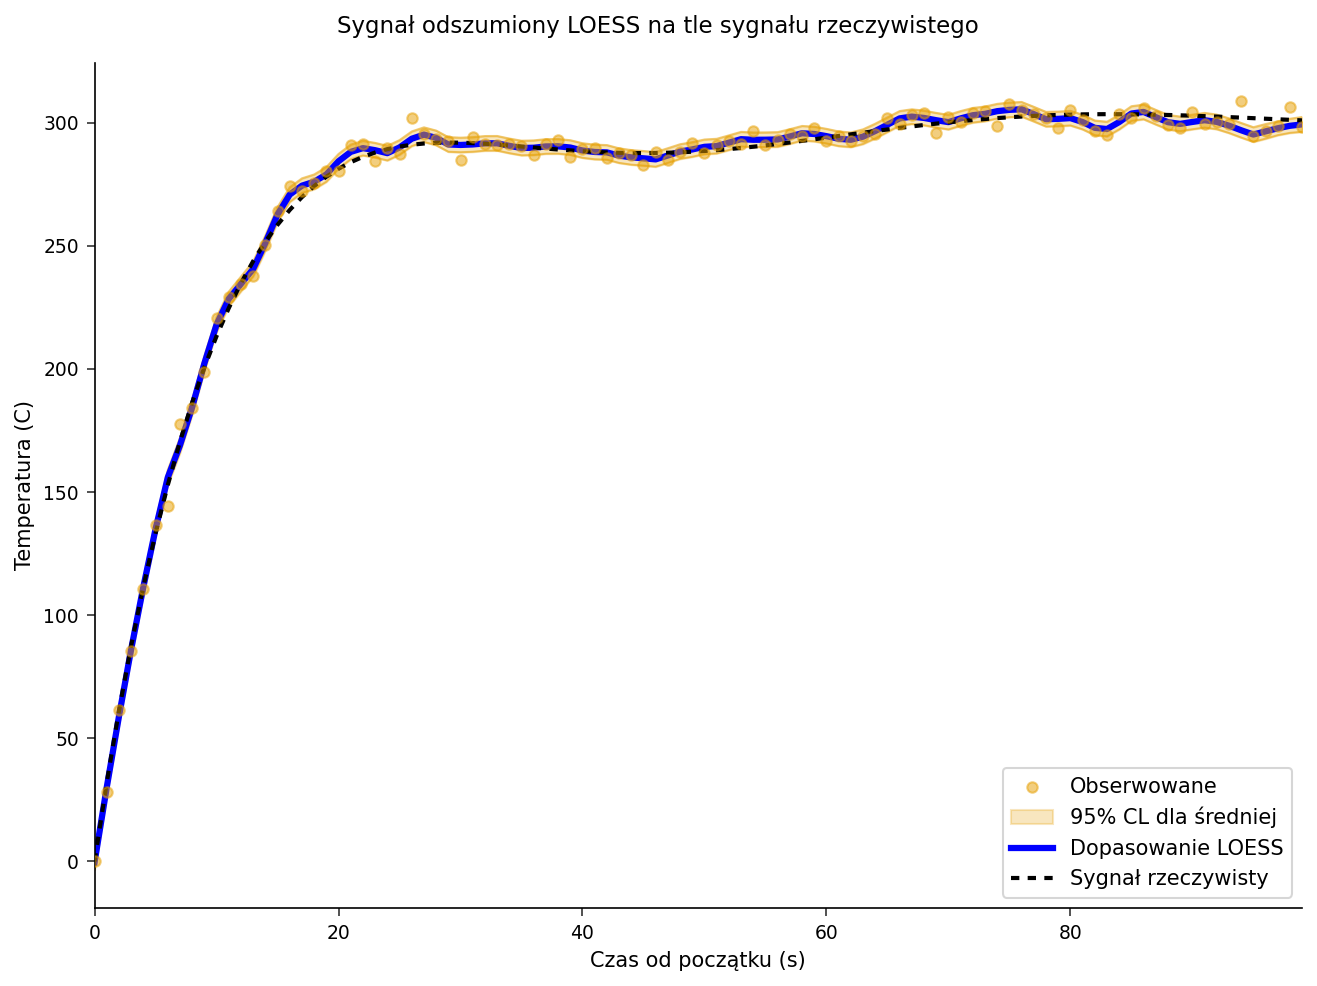

In [5]:
PROCEDURA SORTUJ DANE=fitted; WEDŁUG t; WYKONAJ;

ODS GRAPHICS ON;

PROCEDURA SGPLOT DANE=fitted;
    SCATTER x=t y=temp / MARKERATTRS=(SYMBOL=circlefilled size=5)
            TRANSPARENCY=0.5 legendlabel='Obserwowane';
    BAND x=t lower=lower upper=upper / TRANSPARENCY=0.5
         legendlabel='95% CL dla średniej';
    SERIES x=t y=temp_hat / LINEATTRS=(thickness=3 color=blue)
           legendlabel='Dopasowanie LOESS';
    SERIES x=t y=truth / LINEATTRS=(thickness=2 pattern=shortdash color=black)
           legendlabel='Sygnał rzeczywisty';
    XAXIS ETYKIETA='Czas od początku (s)';
    YAXIS ETYKIETA='Temperatura (C)';
    TYTUŁ 'Sygnał odszumiony LOESS na tle sygnału rzeczywistego';
WYKONAJ;

ODS GRAPHICS OFF;

## Krok 6 — Diagnostyka reszt

Reszty (obserwowane minus dopasowane) powinny wyglądać jak bezstrukturalny szum wyśrodkowany na zerze. Jakikolwiek pozostały trend sygnalizowałby niedostateczne wygładzenie lub pominiętą cechę. Wykreślamy reszty względem czasu i podsumowujemy ich rozrzut — odchylenie standardowe reszt wychodzi na poziomie 3.10°C, nieco poniżej wprowadzonego przez nas szumu 4°C, ponieważ lokalne dopasowanie pochłania jego niewielką część.

                           Podsumowanie dopasowania LOESS (przepustowość wybrana przez AICC)                            

                                     Podsumowanie reszt (odzyskany szum pomiarowy)                                      

                                                  The MEANS Procedure

 Variable  Label              N        Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------------------
 RESID     Reszta (C)       100       0.139       3.096     -11.688      11.909
 ------------------------------------------------------------------------------




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg
NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


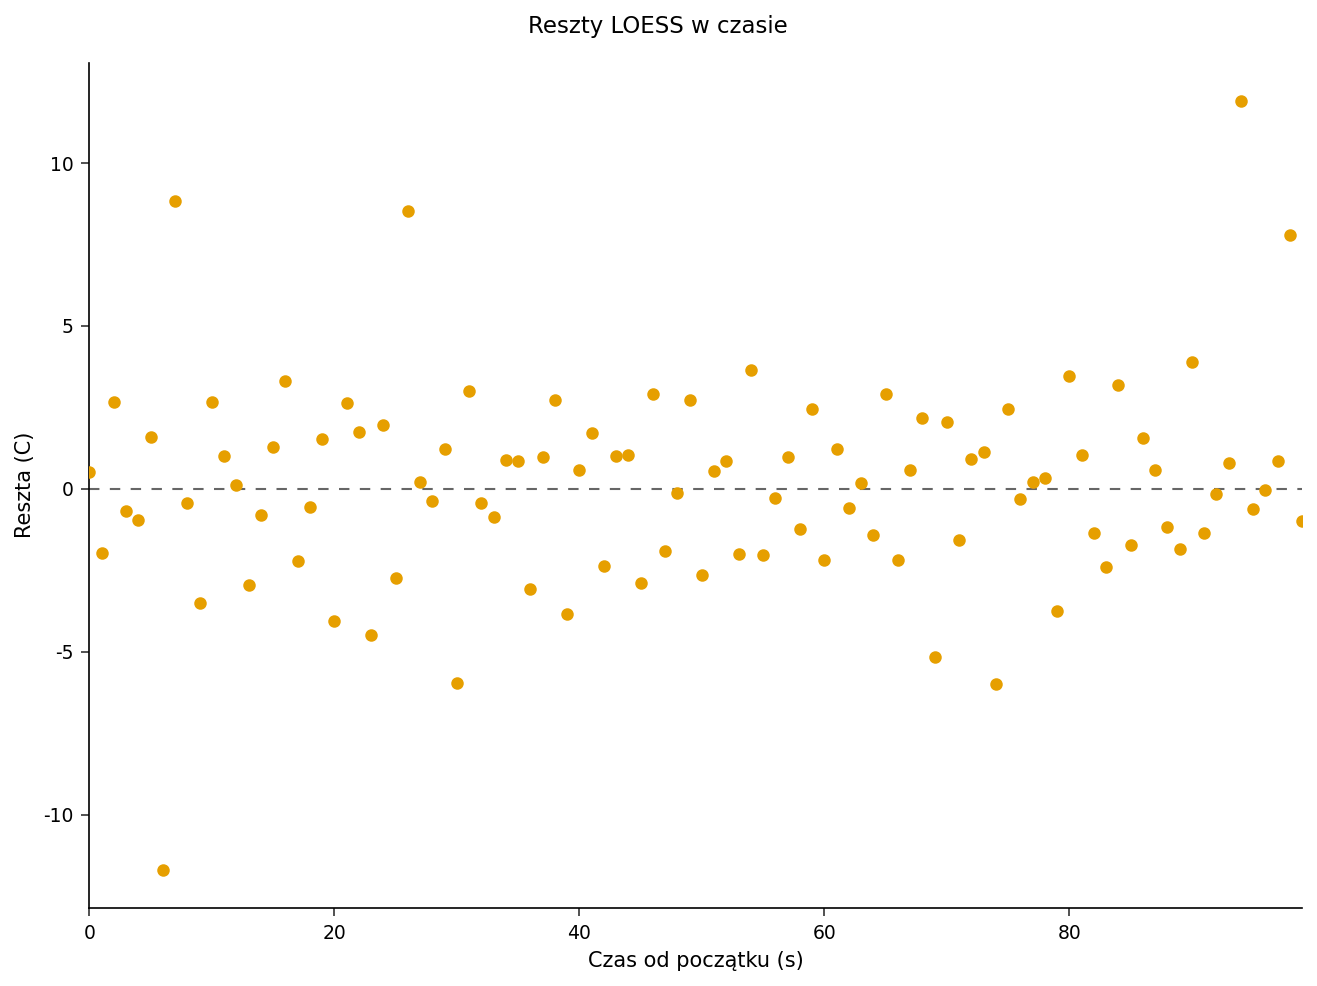

In [6]:
ODS GRAPHICS ON;

PROCEDURA SGPLOT DANE=fitted;
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=shortdash);
    SCATTER x=t y=resid / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS ETYKIETA='Czas od początku (s)';
    YAXIS ETYKIETA='Reszta (C)';
    TYTUŁ 'Reszty LOESS w czasie';
WYKONAJ;

ODS GRAPHICS OFF;

PROCEDURA ŚREDNIE DANE=fitted n mean std MIN MAX maxdec=3;
    ETYKIETA resid='Reszta (C)';
    ZMIENNA resid;
    TYTUŁ 'Podsumowanie reszt (odzyskany szum pomiarowy)';
WYKONAJ;

## Krok 7 — Ocena regularnej siatki monitorującej dla SPC

Znaczniki czasu czujnika nie muszą być rozmieszczone równomiernie, ale wykres kontrolny wymaga sygnału o stałym takcie. Budujemy jednorodną 60-punktową siatkę czasową i stosujemy do niej dopasowany model LOESS za pomocą instrukcji `SCORE`, żądając granic ufności. Ocenione wartości to czysty, równomiernie rozmieszczony sygnał gotowy do zasilenia procedury SPC.

In [7]:
DANE grid;
    POWTÓRZ t = 0 TO 99 WEDŁUG 99/59;
        WYJŚCIE;
    KONIEC;
WYKONAJ;

PROCEDURA loess DANE=sensor;
    MODEL temp = t / DEGREE=2 select=AICC CLM ALPHA=0.05;
    SCORE DANE=grid CLM print;
    TYTUŁ 'LOESS oceniony na jednorodnej siatce monitorującej';
WYKONAJ;

                                     Podsumowanie reszt (odzyskany szum pomiarowy)                                      


                                                  The LOESS Procedure

Dependent Variable: temp
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: DATA grid


NOTE: Wrote grid (60 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC LOESS data=sensor

NOTE: Using Python wrapper for LOESS estimation
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Krok 8 — Ilościowe określenie odszumiania

Na koniec porównujemy surowy sygnał i oszacowanie LOESS ze znaną prawdą. Błąd średniokwadratowy wygładzonego sygnału powinien być znacznie mniejszy niż błąd surowych odczytów, co potwierdza, że LOESS usunął szum pomiarowy, zachowując przy tym narastanie podczas rozgrzewania i przeregulowanie.

In [8]:
DANE accuracy;
    USTAW fitted;
    raw_sq_err   = (temp     - truth)**2;
    loess_sq_err = (temp_hat - truth)**2;
WYKONAJ;

PROCEDURA ŚREDNIE DANE=accuracy mean maxdec=3;
    ZMIENNA raw_sq_err loess_sq_err;
    ETYKIETA raw_sq_err   = 'MSE odczytów surowych względem prawdy'
          loess_sq_err = 'MSE dopasowania LOESS względem prawdy';
    TYTUŁ 'Skuteczność odszumiania: surowe dane vs. LOESS';
WYKONAJ;

                                     Skuteczność odszumiania: surowe dane vs. LOESS                                     

                                                  The MEANS Procedure

 Variable      Label                                             Mean
 --------------------------------------------------------------------
 raw_sq_err    MSE odczytów surowych względem prawdy           14.774
 loess_sq_err  MSE dopasowania LOESS względem prawdy            6.629
 --------------------------------------------------------------------




NOTE: DATA accuracy


NOTE: Read 100 rows from fitted.
NOTE: Wrote accuracy (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpretacja wyników

- **Automatyczna przepustowość.** `select=AICC` wybrało parametr wygładzania **0.08** bez ręcznego strojenia, co odpowiada w przybliżeniu **8 równoważnym parametrom** — wystarczająco dużo lokalnej elastyczności, aby podążać za rozgrzewaniem, przeregulowaniem i spadkiem, jednocześnie wygładzając szum.
- **Wierne odzyskanie.** Dopasowana krzywa ściśle śledzi ukryty sygnał `truth` na całej długości narastania, szczytu przeregulowania w pobliżu t = 28 oraz ogona ustalania się, co pokazuje, że LOESS odzyskał dowolny nieliniowy sygnał bez żadnych założeń parametrycznych.
- **Czyste reszty.** Reszty rozpraszają się wokół zera z odchyleniem standardowym **3.10°C** (średnia 0.14, zakres od −11.7 do 11.9) i nie wykazują żadnego pozostałego trendu czasowego — dowód, że model nie jest ani nadmiernie, ani niedostatecznie wygładzony.
- **Mierzalne odszumianie.** Względem prawdy odniesienia oszacowanie LOESS obniża błąd średniokwadratowy z **14.77** (odczyty surowe) do **6.63** — redukcja o 55%, główna korzyść dla monitorowania procesu.
- **Wynik gotowy do SPC.** Krok SCORE dostarczył odszumiony sygnał na jednorodnej 60-punktowej siatce z granicami ufności, dokładnie w formie, jaką konsumuje dalszy wykres kontrolny.

**Wniosek:** Gdy czujnik procesowy generuje gładki, ale zaszumiony sygnał o nieznanej postaci, PROC LOESS jest samostrojącym się sposobem o niskich założeniach, aby wydobyć leżący u podstaw trend, dołączyć granice niepewności i ponownie spróbkować go na siatkę monitorującą — wszystko to bez zobowiązywania się do modelu parametrycznego, którego fizyka może nie uzasadniać.